In [ ]:
# from google.colab import files
# uploaded = files.upload()

NB is based on posterior probalibilty of an event, So what is the probablity of train if it is cloudy day.

What is posterior probalibilty ?
  - Literal meaning coming after or back of something.
  - Probability of an event which occured after one of the event which already occured ?

We are checking the probaility of occurence of a Word like Dear, Friend and Lunch, Money in a Spam and non-spam email as below


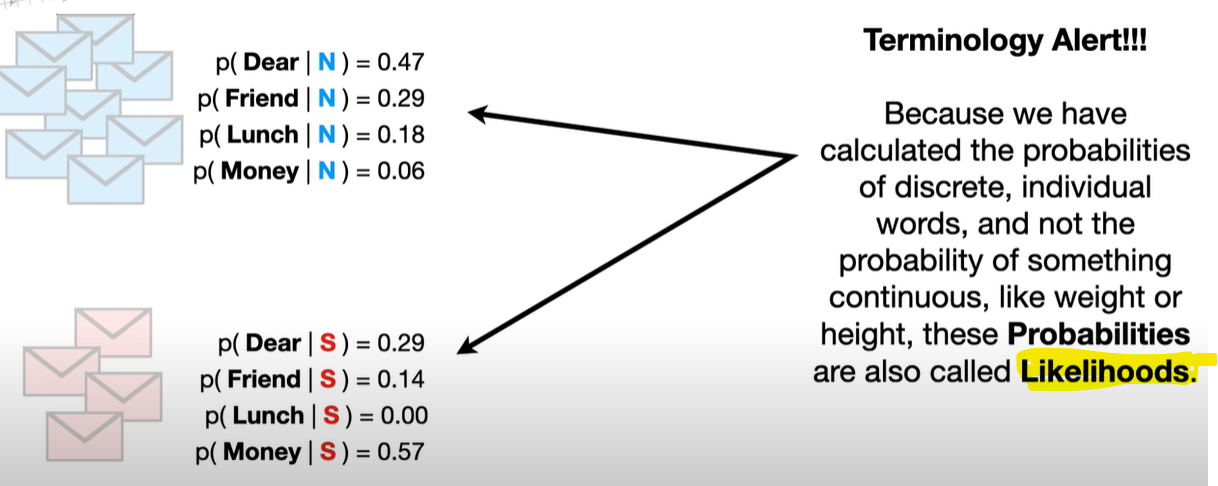


**Assumption of NB Classifier**

1. Naive Bayes classifier assumes that the presence of a particular feature in a class is unreleated to the presence of any other feature.

i.e Presence of the word "Dear" to classify the email as Non-Spam is independent of Presence of the word "Friend" to classify the email as Non-Spam


**What makes NB so naive ?**

It makes such assumptions that may or may not be correct.


Baey theorem with sample data

In [5]:
from collections import defaultdict
import pandas as pd

# Dataset
data = [
    ('<30', 'High', 'No'),
    ('<30', 'High', 'No'),
    ('30–40', 'High', 'Yes'),
    ('>40', 'Medium', 'Yes'),
    ('>40', 'Low', 'Yes'),
    ('>40', 'Low', 'No'),
    ('30–40', 'Low', 'Yes'),
    ('<30', 'Medium', 'No'),
    ('<30', 'Low', 'Yes'),
    ('>40', 'Medium', 'Yes'),
    ('<30', 'Medium', 'Yes'),
    ('30–40', 'Medium', 'Yes'),
    ('30–40', 'High', 'Yes'),
    ('>40', 'Medium', 'No'),
]

df = pd.DataFrame(data, columns=['Age', 'Income', 'Buys'])
df

,Age,Income,Buys
0,<30,High,No
1,<30,High,No
2,30–40,High,Yes
3,>40,Medium,Yes
4,>40,Low,Yes
5,>40,Low,No
6,30–40,Low,Yes
7,<30,Medium,No
8,<30,Low,Yes
9,>40,Medium,Yes


In [6]:
# prompt: Get count frequency for the data frame object

# Function to calculate count frequency for each column
def get_count_frequency(df):
    frequency = {}
    for col in df.columns:
        frequency[col] = df[col].value_counts().to_dict()
    return frequency

# Get count frequency for the DataFrame
count_frequency = get_count_frequency(df)
count_frequency

{'Age': {'<30': 5, '>40': 5, '30–40': 4},
 'Income': {'Medium': 6, 'High': 4, 'Low': 4},
 'Buys': {'Yes': 9, 'No': 5}}

In [2]:
# Count frequencies
def get_probabilities(data):
    label_counts = defaultdict(int)
    feature_counts = defaultdict(lambda: defaultdict(int))

    for age, income, label in data:
        label_counts[label] += 1
        feature_counts['Age', label][age] += 1
        feature_counts['Income', label][income] += 1

    print("label count \n", label_counts, label_counts.items(),"\n")
    print("label count items\n", label_counts.items(),"\n")
    print("feature Count \n", feature_counts,"\n")
    print("feature Count items \n", feature_counts.items(),"\n")

    total = sum(label_counts.values())
    probs = {
        'P(Label)': {label: count / total for label, count in label_counts.items()},
        'P(Feature|Label)': {}
    }

    for (feature, label), values in feature_counts.items():
        total_label = label_counts[label]
        probs['P(Feature|Label)'][(feature, label)] = {
            val: count / total_label for val, count in values.items()
        }

        print("P(Label) \n", probs['P(Label)'],"\n")
        print("P(Feature|Label) \n", probs['P(Feature|Label)'],"\n")

    return probs, label_counts



In [3]:
get_probabilities(data)

label count 
 defaultdict(<class 'int'>, {'No': 5, 'Yes': 9}) dict_items([('No', 5), ('Yes', 9)]) 

label count items
 dict_items([('No', 5), ('Yes', 9)]) 

feature Count 
 defaultdict(<function get_probabilities.<locals>.<lambda> at 0x7dab6731eb60>, {('Age', 'No'): defaultdict(<class 'int'>, {'<30': 3, '>40': 2}), ('Income', 'No'): defaultdict(<class 'int'>, {'High': 2, 'Low': 1, 'Medium': 2}), ('Age', 'Yes'): defaultdict(<class 'int'>, {'30–40': 4, '>40': 3, '<30': 2}), ('Income', 'Yes'): defaultdict(<class 'int'>, {'High': 2, 'Medium': 4, 'Low': 3})}) 

feature Count items 
 dict_items([(('Age', 'No'), defaultdict(<class 'int'>, {'<30': 3, '>40': 2})), (('Income', 'No'), defaultdict(<class 'int'>, {'High': 2, 'Low': 1, 'Medium': 2})), (('Age', 'Yes'), defaultdict(<class 'int'>, {'30–40': 4, '>40': 3, '<30': 2})), (('Income', 'Yes'), defaultdict(<class 'int'>, {'High': 2, 'Medium': 4, 'Low': 3}))]) 

P(Label) 
 {'No': 0.35714285714285715, 'Yes': 0.6428571428571429} 

P(Feature|Label)

({'P(Label)': {'No': 0.35714285714285715, 'Yes': 0.6428571428571429},
  'P(Feature|Label)': {('Age', 'No'): {'<30': 0.6, '>40': 0.4},
   ('Income', 'No'): {'High': 0.4, 'Low': 0.2, 'Medium': 0.4},
   ('Age', 'Yes'): {'30–40': 0.4444444444444444,
    '>40': 0.3333333333333333,
    '<30': 0.2222222222222222},
   ('Income', 'Yes'): {'High': 0.2222222222222222,
    'Medium': 0.4444444444444444,
    'Low': 0.3333333333333333}}},
 defaultdict(int, {'No': 5, 'Yes': 9}))

In [ ]:
# Prediction using Bayes Theorem
def predict(age, income, probs, label_counts):
    results = {}
    for label in label_counts:
        prior = probs['P(Label)'][label]
        p_age = probs['P(Feature|Label)'].get(('Age', label), {}).get(age, 1e-6)
        p_income = probs['P(Feature|Label)'].get(('Income', label), {}).get(income, 1e-6)
        results[label] = prior * p_age * p_income
    return results

# Run
probs, label_counts = get_probabilities(data)

# Predict for: Age = <30, Income = Medium
prediction = predict('<30', 'Medium', probs, label_counts)

print("Posterior probabilities:")
for label, prob in prediction.items():
    print(f"P(Buys={label}) =", round(prob, 4))

# Output max prediction
predicted_label = max(prediction, key=prediction.get)
print("\nPrediction:", predicted_label)

### **1. Import the required packages**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split

### **2. Reading and Exploring the Data**

In [ ]:
spam_df = pd.read_csv('emails.csv')

In [ ]:
spam_df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [ ]:
spam_df.shape

(5728, 2)

### **Visualize the Data**

In [ ]:
spam_df['spam'] == 0

,spam
0,False
1,False
2,False
3,False
4,False
...,...
5723,True
5724,True
5725,True
5726,True


In [ ]:
spam_df[spam_df['spam'] == 0]  #print all the non-spam messages

,text,spam
1368,"Subject: hello guys , i ' m "" bugging you "" f...",0
1369,Subject: sacramento weather station fyi - - ...,0
1370,Subject: from the enron india newsdesk - jan 1...,0
1371,Subject: re : powerisk 2001 - your invitation ...,0
1372,Subject: re : resco database and customer capt...,0
...,...,...
5723,Subject: re : research and development charges...,0
5724,"Subject: re : receipts from visit jim , than...",0
5725,Subject: re : enron case study update wow ! a...,0
5726,"Subject: re : interest david , please , call...",0


In [ ]:
spam_df[spam_df['spam'] == 1]  #print all the spam messages

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1
...,...,...
1363,Subject: are you ready to get it ? hello ! v...,1
1364,Subject: would you like a $ 250 gas card ? do...,1
1365,"Subject: immediate reply needed dear sir , i...",1
1366,Subject: wanna see me get fisted ? fist bang...,1


In [ ]:
spam_df['spam'].value_counts()

,count
spam,
0,4360
1,1368


In [ ]:
#check for the duplicates
spam_df.duplicated().sum()  #print the number of duplicate messages in our data

np.int64(33)

In [ ]:
#print all the duplicate rows
spam_df[spam_df.duplicated()]

,text,spam
2155,Subject: research allocations to egm hi becky...,0
2260,Subject: departure of grant masson the resear...,0
2412,"Subject: re : schedule and more . . jinbaek ,...",0
2473,"Subject: day off tuesday stinson , i would l...",0
2763,"Subject: re : your mail zhendong , dr . kami...",0
3123,"Subject: re : grades pam , the students rese...",0
3152,Subject: tiger evals - attachment tiger hosts...,0
3248,"Subject: re : i am zhendong zhendong , thank...",0
3249,Subject: hello from enron dear dr . mcmullen ...,0
3387,"Subject: term paper dr . kaminski , attached...",0


In [ ]:
#drop all the duplicate rows
spam_df.drop_duplicates(inplace = True)

In [ ]:
spam_msgs = spam_df[spam_df['spam'] == 1]
non_spam_msgs = spam_df[spam_df['spam'] == 0]

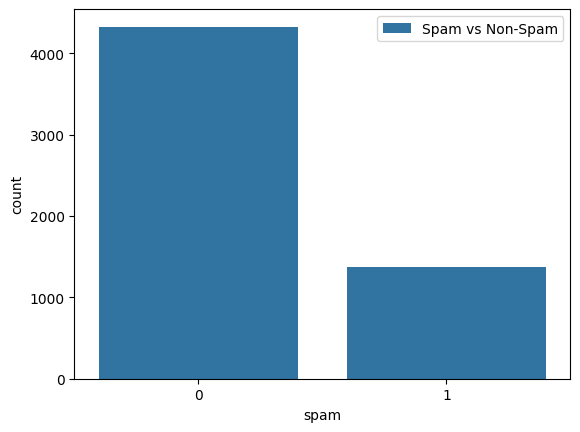

In [ ]:
sns.countplot(x = 'spam', data = spam_df, label = 'Spam vs Non-Spam')
plt.show()

In [ ]:
spam_df['spam'].value_counts()  #to check the imbalance in the data

,count
spam,
0,4327
1,1368


### **Apply CountVectorizer Method to our data to encode it**

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()

vectorized_input_data = vectorizer.fit_transform(spam_df['text'])

In [ ]:
vectorizer.get_feature_names_out()[8000:8500]

array(['cassandra', 'cassel', 'cassette', 'cassettes', 'cassia', 'cassim',
       'cassino', 'cast', 'casta', 'castagnola', 'castaneda', 'caster',
       'castillo', 'castle', 'castleman', 'castlereagh', 'castletown',
       'castro', 'casts', 'casual', 'casualty', 'casuistical', 'casy',
       'cat', 'catagnola', 'catalog', 'catalogers', 'catalogs',
       'catalogue', 'catalogues', 'cataloguing', 'catalysis', 'catalyst',
       'catalytic', 'catanese', 'catastrophe', 'catastrophes',
       'catastrophic', 'catastrophical', 'catawba', 'catch', 'catches',
       'catching', 'catchy', 'categoric', 'categorical', 'categorically',
       'categories', 'categorized', 'category', 'catenae', 'cater',
       'catered', 'catering', 'caters', 'cates', 'catex', 'cathedra',
       'catherine', 'cathey', 'cathodic', 'catholic', 'cathy', 'catlons',
       'cato', 'catriona', 'catskill', 'cattiesinc', 'cattigan', 'cattle',
       'cattlepen', 'catv', 'caucasian', 'caucasus', 'caucus', 'caucuses',
  

In [ ]:
vectorized_input_data = vectorizer.fit_transform(spam_df['text'])


In [ ]:
vectorized_input_data


<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 704610 stored elements and shape (5695, 37303)>

### **Machine Learning Process**

In [ ]:
X = vectorized_input_data
y = spam_df['spam']

In [ ]:
#splitting the data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 100)

### **Apply Multinomial Naive Bayes Algorithm to the data**

There are three variants of Naive Bayes:
1. Gaussian Naive Bayes.
2. Multinomial Naive Bayes.
3. Bernoulli Naive Bayes.

In [ ]:
nb_classifier = MultinomialNB()
nb_classifier.fit(X_train, y_train)

MultinomialNB()

In [ ]:
y_pred = nb_classifier.predict(X_test)

In [ ]:
accuracy_score(y_test, y_pred)

0.9894644424934153

In [ ]:
roc_auc_score(y_test, y_pred)

np.float64(0.9918168009788616)

In [ ]:
from sklearn.metrics import precision_score, recall_score

In [ ]:
print(precision_score(y_test, y_pred))
print(recall_score(y_test, y_pred))

0.9612676056338029
0.9963503649635036


### **Let's try this model on some new messages.**

In [ ]:
msgs = ['Congratulations, you have a pre-approved loan of 50000 US dollars. No documentation required.',
        'Can we have a quick meeting tomorrow at 5 PM?',
        'Get annual cashback of upto INR 18000 with HDFC credit card.']

In [ ]:
msgs_vectorized = vectorizer.transform(msgs)

In [ ]:
nb_classifier.predict(msgs_vectorized)

array([1, 0, 1])